   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5 

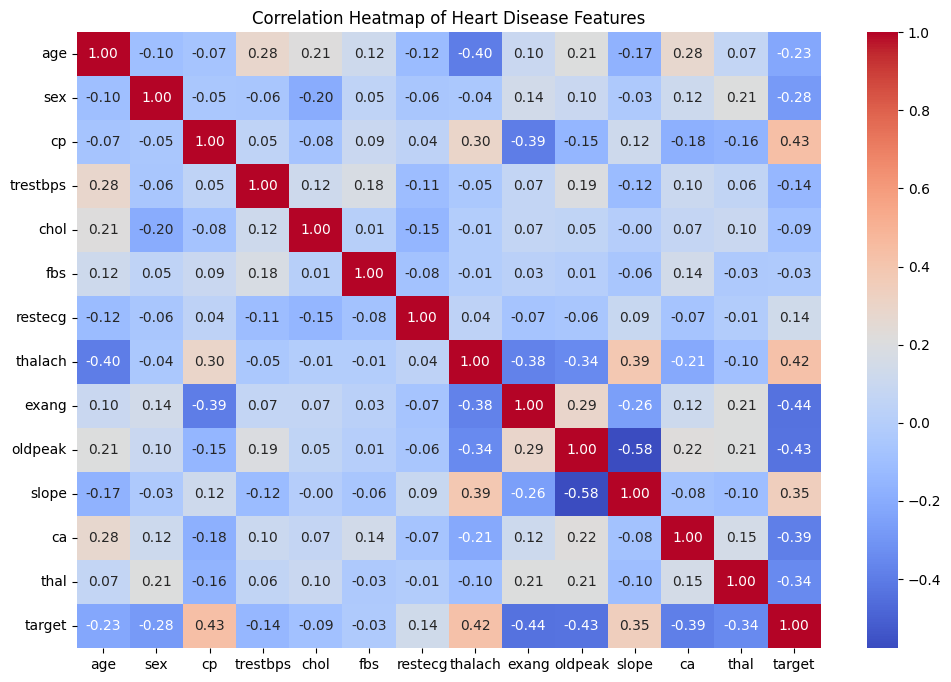

C:\Users\Hait\AppData\Local\Temp\ipykernel_6368\807121505.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=heart_df, palette='Set2')


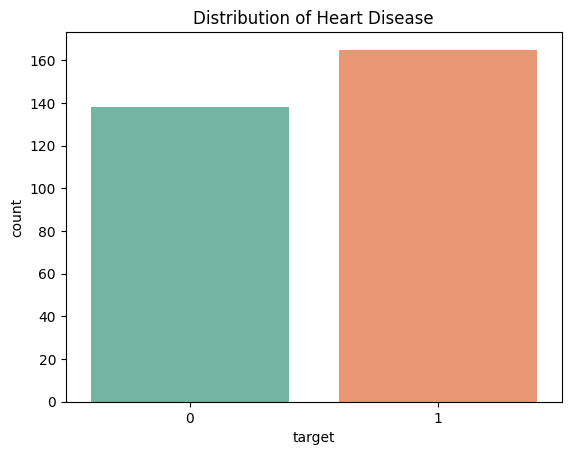

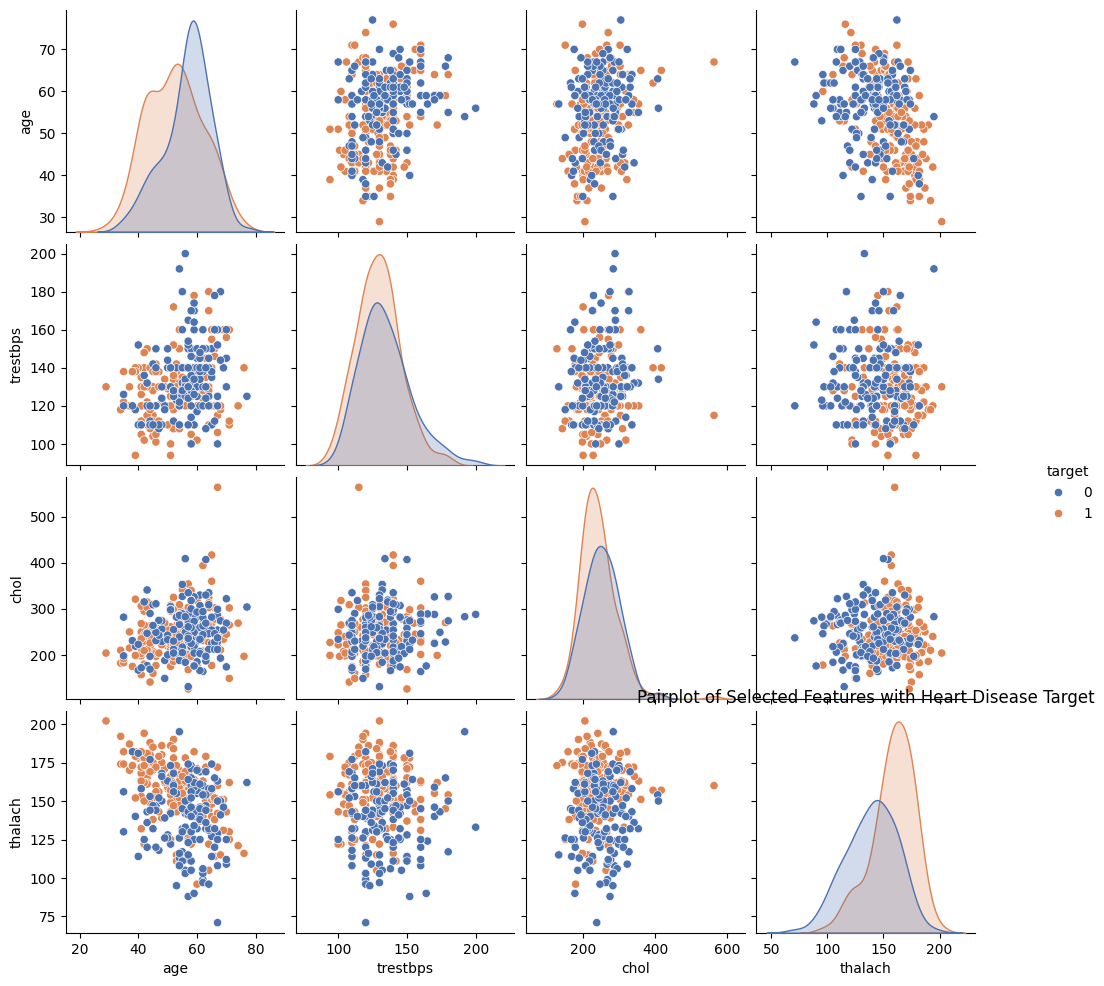

              precision    recall  f1-score   support

           0       0.82      0.80      0.81        41
           1       0.84      0.86      0.85        50

    accuracy                           0.84        91
   macro avg       0.83      0.83      0.83        91
weighted avg       0.83      0.84      0.83        91

Feature ranking:
age: 0.1443
thalach: 0.1283
oldpeak: 0.1208
ca: 0.1148
cp: 0.1069
thal: 0.0923
trestbps: 0.0768
chol: 0.0716
exang: 0.0519
sex: 0.0440
restecg: 0.0230
slope: 0.0186
fbs: 0.0067


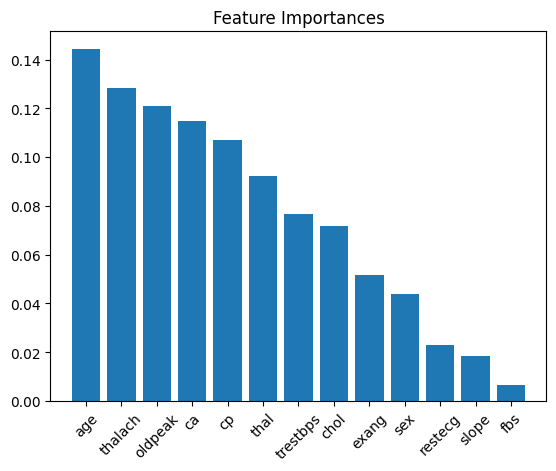

In [8]:
#import libraries and resoruces
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import f1_score, r2_score, accuracy_score,classification_report
from sklearn import datasets
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

#Load Data
heart_df = pd.read_csv("heart_disease.csv")

#- Data overview
print(heart_df.head())
print(heart_df.info())
print(heart_df.describe())

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heart_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Heart Disease Features')
plt.show()

# Distribution of target variable
sns.countplot(x='target', data=heart_df, palette='Set2')
plt.title('Distribution of Heart Disease')
plt.show()

# Pairplot for selected features
sns.pairplot(heart_df[['age', 'trestbps', 'chol', 'thalach', 'target']], hue='target', palette='deep')
plt.title('Pairplot of Selected Features with Heart Disease Target')
plt.show()

X = heart_df.drop(columns='target')
y = heart_df['target']

X_Train, X_Test, Y_Train, Y_Test = train_test_split(X,y, test_size=0.3, random_state=42)
model = GradientBoostingClassifier(loss = 'log_loss', n_estimators=50, learning_rate=0.05, max_depth=5, subsample=0.1)

model.fit(X_Train, Y_Train)

predictions = model.predict(X_Test)

print(classification_report(Y_Test,predictions))

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

# Print feature ranking
print("Feature ranking:")
for f in range(X.shape[1]):
    print(f"{X.columns[indices[f]]}: {importances[indices[f]]:.4f}")

# Plot the feature importances
plt.figure()
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), np.array(X.columns)[indices], rotation=45)
plt.xlim([-1, X.shape[1]])
plt.show()
